In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

rootdir = "/opt/img/effdl-cifar10/"
working_dir = "/users/local/myworkingdir"

os.makedirs(working_dir, exist_ok=True)

train_embeddings_path = os.path.join(working_dir, "dinov2_train_embeddings.pt")
test_embeddings_path = os.path.join(working_dir, "dinov2_test_embeddings.pt")
linear_probe_path = os.path.join(working_dir, "linear_probe.pth")
mlp_head_path = os.path.join(working_dir, "mlp_head.pth")

Device: cuda
GPU: NVIDIA GeForce GTX 1080


In [3]:
torch.hub.set_dir(working_dir)

backbone = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14"
)

backbone.eval()
backbone.to(device)

for param in backbone.parameters():
    param.requires_grad = False

print("DINOv2 loaded and frozen.")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /users/local/myworkingdir/main.zip
/users/local/myworkingdir/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/users/local/myworkingdir/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/users/local/myworkingdir/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /users/local/myworkingdir/checkpoints/dinov2_vits14_pretrain.pth
100.0%


DINOv2 loaded and frozen.


In [4]:
transform_dino = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [5]:
train_dataset = CIFAR10(
    root=rootdir,
    train=True,
    download=True,
    transform=transform_dino
)

test_dataset = CIFAR10(
    root=rootdir,
    train=False,
    download=True,
    transform=transform_dino
)

class_names = train_dataset.classes

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Classes:", class_names)

Files already downloaded and verified
Files already downloaded and verified
Train size: 50000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
extraction_batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=extraction_batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=extraction_batch_size,
    shuffle=False
)

In [7]:
def extract_embeddings(loader, model, device):
    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model.forward_features(images)

            features = outputs["x_norm_clstoken"]

            all_features.append(features.cpu())
            all_labels.append(labels)

    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return all_features, all_labels

In [8]:
train_features, train_labels = extract_embeddings(
    train_loader,
    backbone,
    device
)

test_features, test_labels = extract_embeddings(
    test_loader,
    backbone,
    device
)

print("Train features shape:", train_features.shape)
print("Train labels shape:", train_labels.shape)

print("Test features shape:", test_features.shape)
print("Test labels shape:", test_labels.shape)

torch.save(
    {
        "features": train_features,
        "labels": train_labels
    },
    train_embeddings_path
)

torch.save(
    {
        "features": test_features,
        "labels": test_labels
    },
    test_embeddings_path
)

print("Embeddings saved.")

Train features shape: torch.Size([50000, 384])
Train labels shape: torch.Size([50000])
Test features shape: torch.Size([10000, 384])
Test labels shape: torch.Size([10000])
Embeddings saved.


In [15]:
del backbone

if device.type == "cuda":
    torch.cuda.empty_cache()

print("Backbone removed from memory.")

Backbone removed from memory.


In [16]:
train_data = torch.load(train_embeddings_path)
test_data = torch.load(test_embeddings_path)

X_train = train_data["features"]
y_train = train_data["labels"]

X_test = test_data["features"]
y_test = test_data["labels"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([50000, 384])
y_train: torch.Size([50000])
X_test: torch.Size([10000, 384])
y_test: torch.Size([10000])


/tmp/ipykernel_25781/4129789033.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_data = torch.load(train_embeddings_path)
/tmp/ipykernel_25781/4129789033.py:2: Futu

In [17]:
classifier_batch_size = 128

train_tensor_dataset = TensorDataset(X_train, y_train)
test_tensor_dataset = TensorDataset(X_test, y_test)

train_embedding_loader = DataLoader(
    train_tensor_dataset,
    batch_size=classifier_batch_size,
    shuffle=True
)

test_embedding_loader = DataLoader(
    test_tensor_dataset,
    batch_size=classifier_batch_size,
    shuffle=False
)

In [18]:
def train_one_epoch_classifier(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(features)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)

        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate_classifier(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * features.size(0)

            _, predicted = torch.max(outputs, dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_predictions

In [19]:
linear_probe = nn.Linear(384, 10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_linear = optim.AdamW(
    linear_probe.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

num_epochs_linear = 20

In [20]:
linear_train_losses = []
linear_test_losses = []

linear_train_accuracies = []
linear_test_accuracies = []

best_linear_acc = 0.0

for epoch in range(num_epochs_linear):
    train_loss, train_acc = train_one_epoch_classifier(
        linear_probe,
        train_embedding_loader,
        criterion,
        optimizer_linear,
        device
    )

    test_loss, test_acc, _, _ = evaluate_classifier(
        linear_probe,
        test_embedding_loader,
        criterion,
        device
    )

    linear_train_losses.append(train_loss)
    linear_test_losses.append(test_loss)

    linear_train_accuracies.append(train_acc)
    linear_test_accuracies.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs_linear}] "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Test loss: {test_loss:.4f} | "
        f"Test acc: {test_acc:.4f}"
    )

    if test_acc > best_linear_acc:
        best_linear_acc = test_acc

        torch.save(
            {
                "net": linear_probe.state_dict(),
                "best_test_acc": best_linear_acc
            },
            linear_probe_path
        )

        print("Best linear probe saved.")

Epoch [1/20] Train loss: 0.2521 | Train acc: 0.9189 | Test loss: 0.1477 | Test acc: 0.9515
Best linear probe saved.
Epoch [2/20] Train loss: 0.1212 | Train acc: 0.9587 | Test loss: 0.1317 | Test acc: 0.9566
Best linear probe saved.
Epoch [3/20] Train loss: 0.1067 | Train acc: 0.9634 | Test loss: 0.1262 | Test acc: 0.9576
Best linear probe saved.
Epoch [4/20] Train loss: 0.1006 | Train acc: 0.9653 | Test loss: 0.1236 | Test acc: 0.9587
Best linear probe saved.
Epoch [5/20] Train loss: 0.0960 | Train acc: 0.9664 | Test loss: 0.1259 | Test acc: 0.9585
Epoch [6/20] Train loss: 0.0930 | Train acc: 0.9680 | Test loss: 0.1354 | Test acc: 0.9558
Epoch [7/20] Train loss: 0.0905 | Train acc: 0.9686 | Test loss: 0.1275 | Test acc: 0.9589
Best linear probe saved.
Epoch [8/20] Train loss: 0.0878 | Train acc: 0.9694 | Test loss: 0.1289 | Test acc: 0.9587
Epoch [9/20] Train loss: 0.0868 | Train acc: 0.9702 | Test loss: 0.1257 | Test acc: 0.9592
Best linear probe saved.
Epoch [10/20] Train loss: 0.085

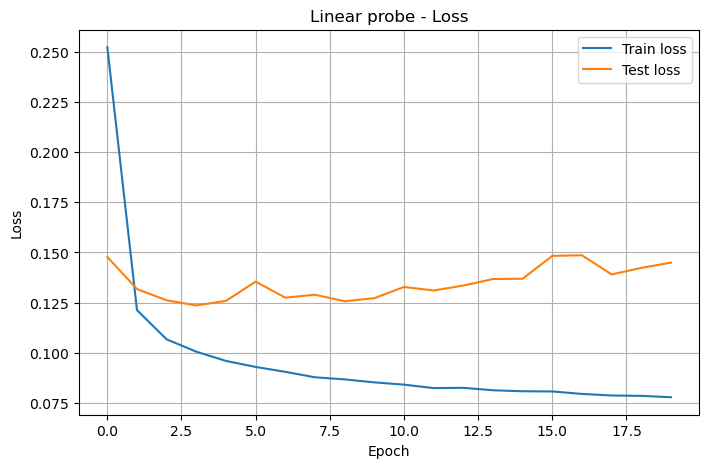

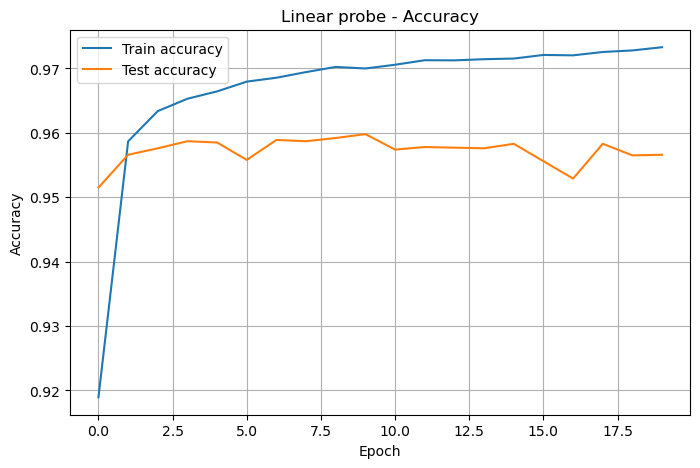

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(linear_train_losses, label="Train loss")
plt.plot(linear_test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Linear probe - Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(linear_train_accuracies, label="Train accuracy")
plt.plot(linear_test_accuracies, label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Linear probe - Accuracy")
plt.legend()
plt.grid()
plt.show()

In [22]:
class MLPHead(nn.Module):
    def __init__(self, input_dim=384, num_classes=10):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [23]:
mlp_head = MLPHead().to(device)

optimizer_mlp = optim.AdamW(
    mlp_head.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

num_epochs_mlp = 20

In [24]:
mlp_train_losses = []
mlp_test_losses = []

mlp_train_accuracies = []
mlp_test_accuracies = []

best_mlp_acc = 0.0

for epoch in range(num_epochs_mlp):
    train_loss, train_acc = train_one_epoch_classifier(
        mlp_head,
        train_embedding_loader,
        criterion,
        optimizer_mlp,
        device
    )

    test_loss, test_acc, _, _ = evaluate_classifier(
        mlp_head,
        test_embedding_loader,
        criterion,
        device
    )

    mlp_train_losses.append(train_loss)
    mlp_test_losses.append(test_loss)

    mlp_train_accuracies.append(train_acc)
    mlp_test_accuracies.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs_mlp}] "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Test loss: {test_loss:.4f} | "
        f"Test acc: {test_acc:.4f}"
    )

    if test_acc > best_mlp_acc:
        best_mlp_acc = test_acc

        torch.save(
            {
                "net": mlp_head.state_dict(),
                "best_test_acc": best_mlp_acc
            },
            mlp_head_path
        )

        print("Best MLP head saved.")

Epoch [1/20] Train loss: 0.1959 | Train acc: 0.9416 | Test loss: 0.1236 | Test acc: 0.9584
Best MLP head saved.
Epoch [2/20] Train loss: 0.1141 | Train acc: 0.9615 | Test loss: 0.1205 | Test acc: 0.9586
Best MLP head saved.
Epoch [3/20] Train loss: 0.0939 | Train acc: 0.9674 | Test loss: 0.1216 | Test acc: 0.9595
Best MLP head saved.
Epoch [4/20] Train loss: 0.0780 | Train acc: 0.9728 | Test loss: 0.1214 | Test acc: 0.9603
Best MLP head saved.
Epoch [5/20] Train loss: 0.0640 | Train acc: 0.9776 | Test loss: 0.1231 | Test acc: 0.9615
Best MLP head saved.
Epoch [6/20] Train loss: 0.0529 | Train acc: 0.9819 | Test loss: 0.1260 | Test acc: 0.9601
Epoch [7/20] Train loss: 0.0436 | Train acc: 0.9848 | Test loss: 0.1303 | Test acc: 0.9610
Epoch [8/20] Train loss: 0.0370 | Train acc: 0.9869 | Test loss: 0.1370 | Test acc: 0.9617
Best MLP head saved.
Epoch [9/20] Train loss: 0.0318 | Train acc: 0.9887 | Test loss: 0.1509 | Test acc: 0.9607
Epoch [10/20] Train loss: 0.0298 | Train acc: 0.9895 | 

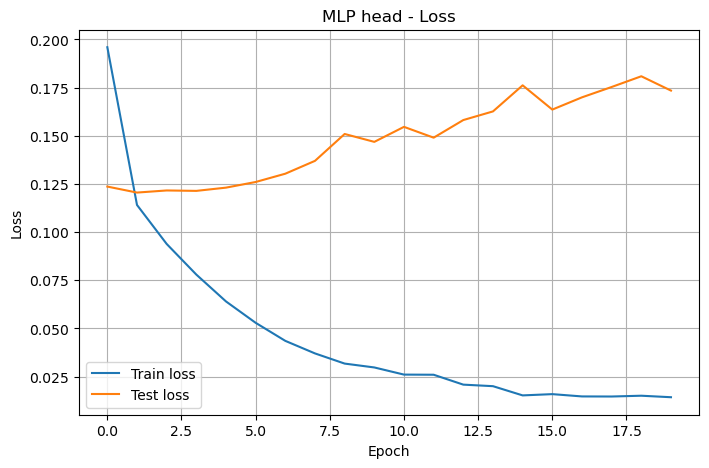

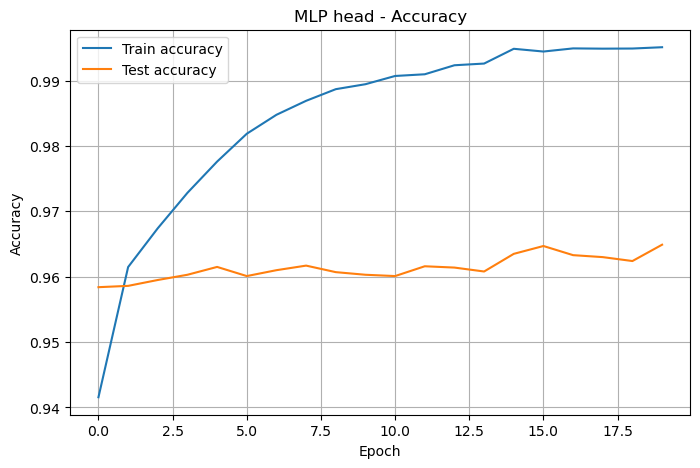

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_train_losses, label="Train loss")
plt.plot(mlp_test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP head - Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(mlp_train_accuracies, label="Train accuracy")
plt.plot(mlp_test_accuracies, label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP head - Accuracy")
plt.legend()
plt.grid()
plt.show()

In [26]:
linear_checkpoint = torch.load(linear_probe_path, map_location=device)
mlp_checkpoint = torch.load(mlp_head_path, map_location=device)

best_linear_probe = nn.Linear(384, 10).to(device)
best_linear_probe.load_state_dict(linear_checkpoint["net"])
best_linear_probe.eval()

best_mlp_head = MLPHead().to(device)
best_mlp_head.load_state_dict(mlp_checkpoint["net"])
best_mlp_head.eval()

print("Best linear test accuracy:", linear_checkpoint["best_test_acc"])
print("Best MLP test accuracy:", mlp_checkpoint["best_test_acc"])

Best linear test accuracy: 0.9598
Best MLP test accuracy: 0.9649


/tmp/ipykernel_25781/2158421901.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  linear_checkpoint = torch.load(linear_probe_path, map_location=device)
/tmp/ipykernel_257

In [27]:
linear_loss, linear_acc, y_true_linear, y_pred_linear = evaluate_classifier(
    best_linear_probe,
    test_embedding_loader,
    criterion,
    device
)

mlp_loss, mlp_acc, y_true_mlp, y_pred_mlp = evaluate_classifier(
    best_mlp_head,
    test_embedding_loader,
    criterion,
    device
)

print("Linear probe accuracy:", linear_acc)
print("MLP head accuracy:", mlp_acc)

print("\nLinear probe classification report:")
print(classification_report(
    y_true_linear,
    y_pred_linear,
    target_names=class_names
))

print("\nMLP head classification report:")
print(classification_report(
    y_true_mlp,
    y_pred_mlp,
    target_names=class_names
))

Linear probe accuracy: 0.9598
MLP head accuracy: 0.9649

Linear probe classification report:
              precision    recall  f1-score   support

    airplane       0.97      0.97      0.97      1000
  automobile       0.98      0.97      0.97      1000
        bird       0.96      0.94      0.95      1000
         cat       0.90      0.92      0.91      1000
        deer       0.94      0.96      0.95      1000
         dog       0.94      0.93      0.93      1000
        frog       0.97      0.96      0.97      1000
       horse       0.98      0.98      0.98      1000
        ship       0.99      0.98      0.98      1000
       truck       0.97      0.98      0.97      1000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000


MLP head classification report:
              precision    recall  f1-score   support

    airplane       0.97      0.97      0.97      1000
  auto

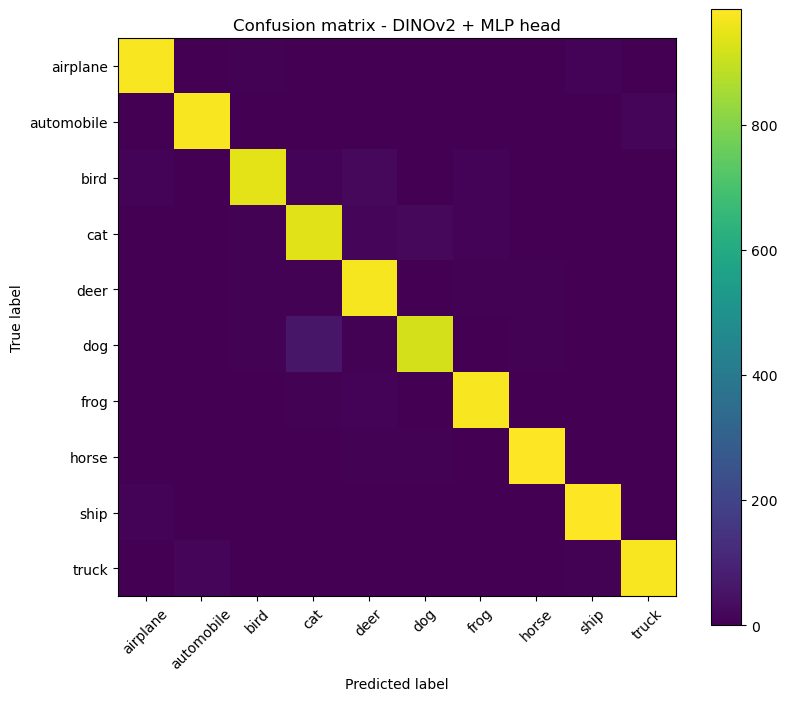

In [28]:
cm = confusion_matrix(y_true_mlp, y_pred_mlp)

plt.figure(figsize=(9, 8))
plt.imshow(cm)
plt.title("Confusion matrix - DINOv2 + MLP head")
plt.colorbar()

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

In [29]:
num_tsne_samples = 2000
rng = np.random.RandomState(seed=42)

indices = rng.choice(
    len(X_train),
    size=num_tsne_samples,
    replace=False
)

X_tsne = X_train[indices].numpy()
y_tsne = y_train[indices].numpy()

print("t-SNE input shape:", X_tsne.shape)

t-SNE input shape: (2000, 384)


In [30]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42
)

X_tsne_2d = tsne.fit_transform(X_tsne)

print("t-SNE output shape:", X_tsne_2d.shape)

t-SNE output shape: (2000, 2)


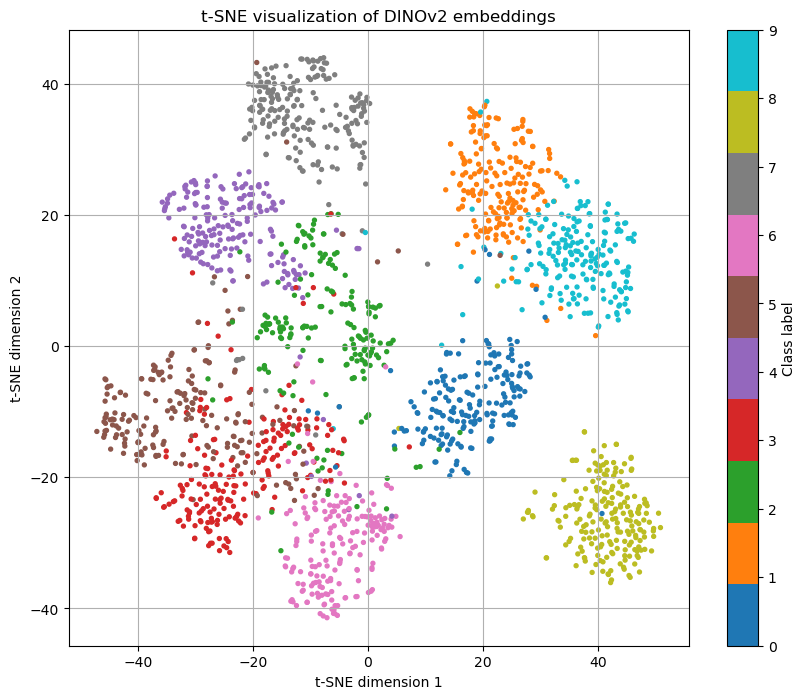

In [31]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_tsne_2d[:, 0],
    X_tsne_2d[:, 1],
    c=y_tsne,
    s=8,
    cmap="tab10"
)

plt.colorbar(scatter, ticks=range(10), label="Class label")
plt.title("t-SNE visualization of DINOv2 embeddings")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.grid()
plt.show()

In [ ]:
resnet_from_scratch_acc = None 

results = {
    "Classifier": [
        "ResNet from scratch",
        "DINOv2 + Linear probe",
        "DINOv2 + MLP head"
    ],
    "Test Accuracy": [
        resnet_from_scratch_acc,
        linear_acc,
        mlp_acc
    ]
}

for classifier, acc in zip(results["Classifier"], results["Test Accuracy"]):
    print(classifier, ":", acc)

ResNet from scratch : None
DINOv2 + Linear probe : 0.9598
DINOv2 + MLP head : 0.9649
